# Problem statement

Your goal is to predict the total_cases label for each (city, year, weekofyear) in the test set. There are two cities, San Juan and Iquitos, with test data for each city spanning 5 and 3 years respectively. You will make one submission that contains predictions for both cities. The data for each city have been concatenated along with a city column indicating the source: sj for San Juan and iq for Iquitos. The test set is a pure future hold-out, meaning the test data are sequential and non-overlapping with any of the training data. Throughout, missing values have been filled as NaNs.

# Libs and macros

In [1]:
# EDA / math
import pandas as pd
import numpy as np
import scipy as sp
import random

# ML
import sklearn as skl
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, ParameterGrid
from sklearn.metrics import mean_absolute_error
from tqdm_joblib import tqdm_joblib

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Processing
import json
import cloudpickle
from pathlib import Path

# ---------------------------------------------------------------------------
# The DengAI package holds every custom transformer, estimator and pipeline used
# below; configs/features.yaml and configs/models.yaml hold the parameters.
# Installed with `pip install -e .` from the repo root.
# ---------------------------------------------------------------------------
try:
    import DengAI
except ModuleNotFoundError:                     # not installed: fall back to the repo root
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent))
    import DengAI

from DengAI import (load_config, load_raw, split_cities,
                    DengueImputer, WeatherHistoryTransformer,
                    CatBoostFeatureSelector, cyclical_encoding, model_features,
                    make_city_pipeline, build_pipelines)
from DengAI.models import ProphetRegressor, SARIMAXRegressor
from DengAI import evaluate as ev

cfg = load_config()
print("DengAI", DengAI.__version__, "| models:", list(cfg.models.models))

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


DengAI 0.1.0 | models: ['catboost', 'prophet', 'sarimax', 'random_forest', 'ridge', 'lasso', 'seasonal_median', 'shape_level']


In [2]:
# SEEDS
RANDOM_SEED = cfg.features.random_seed
DengAI.set_seed(RANDOM_SEED)

2022

# Getting the data

In [3]:
# Paths resolve from the repo root, so this works regardless of the kernel's cwd.
df_train_features, df_train_labels, df_test_features = load_raw()

In [4]:
df_train_features

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451,iq,2010,21,2010-05-28,0.342750,0.318900,0.256343,0.292514,55.30,299.334286,...,45.00,88.765714,55.30,18.485714,9.800000,28.633333,11.933333,35.4,22.4,27.0
1452,iq,2010,22,2010-06-04,0.160157,0.160371,0.136043,0.225657,86.47,298.330000,...,207.10,91.600000,86.47,18.070000,7.471429,27.433333,10.500000,34.7,21.7,36.6
1453,iq,2010,23,2010-06-11,0.247057,0.146057,0.250357,0.233714,58.94,296.598571,...,50.60,94.280000,58.94,17.008571,7.500000,24.400000,6.900000,32.2,19.2,7.4
1454,iq,2010,24,2010-06-18,0.333914,0.245771,0.278886,0.325486,59.67,296.345714,...,62.33,94.660000,59.67,16.815714,7.871429,25.433333,8.733333,31.2,21.0,16.0


In [5]:
df_train_labels

,city,year,weekofyear,total_cases
0,sj,1990,18,4
1,sj,1990,19,5
2,sj,1990,20,4
3,sj,1990,21,3
4,sj,1990,22,6
...,...,...,...,...
1451,iq,2010,21,5
1452,iq,2010,22,8
1453,iq,2010,23,1
1454,iq,2010,24,1


## Duplicate check

Before splitting by city, make sure nothing is counted twice: no duplicated rows, no
duplicated `(city, year, weekofyear)` keys or dates, exactly one label per feature row,
and no two columns carrying the same values. The only hit is `reanalysis_sat_precip_amt_mm`,
a byte-for-byte copy of `precipitation_amt_mm`; `configs/features.yaml` drops it
(`model_features.drop`).

In [ ]:
# One row per check. Everything is zero except the copied rainfall column.
display(ev.duplicate_report(df_train_features, df_train_labels))
display(ev.duplicate_report(df_test_features))

,count,detail
duplicated rows,0,
"duplicated keys ['city', 'year', 'weekofyear']",0,
"duplicated (city, week_start_date)",0,
feature rows without a label,0,
label rows without features,0,
identical columns,1,precipitation_amt_mm == reanalysis_sat_precip_amt_mm


,count,detail
duplicated rows,0,
"duplicated keys ['city', 'year', 'weekofyear']",0,
"duplicated (city, week_start_date)",0,
identical columns,1,precipitation_amt_mm == reanalysis_sat_precip_amt_mm


In [6]:
sj_train_features = df_train_features.query("city == 'sj'").copy()
sj_train_labels = df_train_labels.query("city == 'sj'").copy()
iq_train_features = df_train_features.query("city == 'iq'").copy()
iq_train_labels = df_train_labels.query("city == 'iq'").copy()

sj_test_features = df_test_features.query("city == 'sj'").copy()
iq_test_features = df_test_features.query("city == 'iq'").copy()

# Keep the target for EDA
sj_train_features["total_cases"] = sj_train_labels["total_cases"]
iq_train_features["total_cases"] = iq_train_labels["total_cases"]

In [7]:
# Save raw inputs before the EDA filling below.
sj_train_raw = sj_train_features.drop(columns="total_cases")
iq_train_raw = iq_train_features.drop(columns="total_cases")
sj_test_raw = sj_test_features.copy()
iq_test_raw = iq_test_features.copy()

# Handling NANs

## For San Juan

### Train data

In [8]:
sj_train_features.year.nunique()

19

In [9]:
print(sj_train_features.isna().sum())

city                                       0
year                                       0
weekofyear                                 0
week_start_date                            0
ndvi_ne                                  191
ndvi_nw                                   49
ndvi_se                                   19
ndvi_sw                                   19
precipitation_amt_mm                       9
reanalysis_air_temp_k                      6
reanalysis_avg_temp_k                      6
reanalysis_dew_point_temp_k                6
reanalysis_max_air_temp_k                  6
reanalysis_min_air_temp_k                  6
reanalysis_precip_amt_kg_per_m2            6
reanalysis_relative_humidity_percent       6
reanalysis_sat_precip_amt_mm               9
reanalysis_specific_humidity_g_per_kg      6
reanalysis_tdtr_k                          6
station_avg_temp_c                         6
station_diur_temp_rng_c                    6
station_max_temp_c                         6
station_mi

In [10]:
sj_train_features.columns.shape[0]

25

In [11]:
sj_train_features["weekofyear"].nunique()

53

| Category / Source | Feature | Description |
|---|---|---|
| City and date indicators | `city` | City abbreviation: `sj` for San Juan and `iq` for Iquitos |
| City and date indicators | `week_start_date` | Date in `yyyy-mm-dd` format |
| [NOAA GHCN weather stations][ghcn] | `station_max_temp_c` | Maximum temperature |
| [NOAA GHCN weather stations][ghcn] | `station_min_temp_c` | Minimum temperature |
| [NOAA GHCN weather stations][ghcn] | `station_avg_temp_c` | Average temperature |
| [NOAA GHCN weather stations][ghcn] | `station_precip_mm` | Total precipitation |
| [NOAA GHCN weather stations][ghcn] | `station_diur_temp_rng_c` | Diurnal temperature range |
| [PERSIANN satellite precipitation][persiann] (0.25° × 0.25°) | `precipitation_amt_mm` | Total precipitation |
| [NOAA NCEP reanalysis][ncep] (0.5° × 0.5°) | `reanalysis_sat_precip_amt_mm` | Total precipitation |
| [NOAA NCEP reanalysis][ncep] (0.5° × 0.5°) | `reanalysis_dew_point_temp_k` | Mean dew point temperature |
| [NOAA NCEP reanalysis][ncep] (0.5° × 0.5°) | `reanalysis_air_temp_k` | Average instantaneous air temperature |
| [NOAA NCEP reanalysis][ncep] (0.5° × 0.5°) | `reanalysis_relative_humidity_percent` | Mean relative humidity |
| [NOAA NCEP reanalysis][ncep] (0.5° × 0.5°) | `reanalysis_specific_humidity_g_per_kg` | Mean specific humidity |
| [NOAA NCEP reanalysis][ncep] (0.5° × 0.5°) | `reanalysis_precip_amt_kg_per_m2` | Total precipitation |
| [NOAA NCEP reanalysis][ncep] (0.5° × 0.5°) | `reanalysis_max_air_temp_k` | Maximum air temperature |
| [NOAA NCEP reanalysis][ncep] (0.5° × 0.5°) | `reanalysis_min_air_temp_k` | Minimum air temperature |
| [NOAA NCEP reanalysis][ncep] (0.5° × 0.5°) | `reanalysis_avg_temp_k` | Average daily air temperature |
| [NOAA NCEP reanalysis][ncep] (0.5° × 0.5°) | `reanalysis_tdtr_k` | Diurnal temperature range |
| [NOAA satellite vegetation — NDVI][ndvi] (0.5° × 0.5°) | `ndvi_se` | Pixel southeast of city centroid |
| [NOAA satellite vegetation — NDVI][ndvi] (0.5° × 0.5°) | `ndvi_sw` | Pixel southwest of city centroid |
| [NOAA satellite vegetation — NDVI][ndvi] (0.5° × 0.5°) | `ndvi_ne` | Pixel northeast of city centroid |
| [NOAA satellite vegetation — NDVI][ndvi] (0.5° × 0.5°) | `ndvi_nw` | Pixel northwest of city centroid |

[ghcn]: https://www.ncdc.noaa.gov/oa/climate/ghcn-daily/ "GHCN daily climate data"
[persiann]: https://www.ncei.noaa.gov/products/climate-data-records/precipitation-persiann "PERSIANN satellite precipitation measurements"
[ncep]: https://gdex.ucar.edu/datasets/d093000/ "Climate Forecast System Reanalysis"
[ndvi]: https://www.ncei.noaa.gov/products/climate-data-records/normalized-difference-vegetation-index "CDR Normalized Difference Vegetation Index"

In [12]:
sj_train_features["ndvi_ne"]

0      0.122600
1      0.169900
2      0.032250
3      0.128633
4      0.196200
         ...   
931    0.077850
932   -0.038000
933   -0.155200
934    0.001800
935   -0.037000
Name: ndvi_ne, Length: 936, dtype: float64

Infor about NDVI from Wikipedia:
>> The normalized difference vegetation index (NDVI) is a widely used metric for quantifying the health and density of vegetation using sensor data. It is calculated from spectrometric data at two specific bands: red and near-infrared. The spectrometric data is usually sourced from remote sensors, such as satellites.The metric is popular in industry because of its accuracy. It has a high correlation with the true state of vegetation on the ground. The index is easy to interpret: NDVI will be a value between -1 and 1, where values close to zero will indicate little to no vegetation, negative values are associated with non-land surfaces or water, and higher values correspond to healthy, dense vegetation. It is used in applications such as agriculture, drought monitoring, and ecosystem analysis.

In [13]:
import pandas as pd
from IPython.display import display

def missing_report(df):
    missing = df.sort_values("week_start_date").isna()

    longest_gap = missing.apply(
        lambda s: s.groupby(s.ne(s.shift()).cumsum()).sum().max()
    )

    report = pd.DataFrame({
        "Missing": missing.sum(),
        "Missing (%)": (missing.mean() * 100).round(1),
        "Longest gap (rows)": longest_gap,
    })

    return report.loc[report["Missing"] > 0].sort_values(
        "Missing", ascending=False
    )

print("San Juan")
display(missing_report(sj_train_features))

San Juan


,Missing,Missing (%),Longest gap (rows)
ndvi_ne,191,20.4,15
ndvi_nw,49,5.2,15
ndvi_se,19,2.0,14
ndvi_sw,19,2.0,14
reanalysis_sat_precip_amt_mm,9,1.0,3
precipitation_amt_mm,9,1.0,3
station_min_temp_c,6,0.6,1
station_max_temp_c,6,0.6,1
station_diur_temp_rng_c,6,0.6,1
station_avg_temp_c,6,0.6,1


## Imputter

| City | NDVI | Other numeric environmental features |
|---|---|---|
| San Juan | Week-of-year training medians, then overall training median | Linear interpolation |
| Iquitos | Linear interpolation | Linear interpolation |


In [14]:
# DengueImputer now lives in DengAI/transformers.py. Shown here for reference.
import inspect
print(inspect.getsource(DengueImputer))

class DengueImputer(TransformerMixin, BaseEstimator):
    """Fill missing weather values.

    Seasonal columns (San Juan's NDVI, whose north-east pixel falls over the Atlantic)
    are filled from week-of-year training medians, then the overall training median.
    Everything else is linearly interpolated.

    ``copy`` defaults to ``True`` here, unlike the notebook original -- in-place
    mutation of the caller's frame is surprising, and every pipeline call site
    already passed ``copy=True``.
    """

    def __init__(self, seasonal_columns=(), copy=True):
        self.seasonal_columns = seasonal_columns
        self.copy = copy

    def fit(self, X, y=None):
        excluded = ["city", "year", "weekofyear", "week_start_date", "total_cases"]
        self.feature_columns_ = [c for c in X.columns if c not in excluded]
        self.interpolation_columns_ = [
            c for c in self.feature_columns_ if c not in self.seasonal_columns
        ]
        seasonal = list(self.seasonal

### Fit and fill San Juan training data

In [15]:
ndvi_cols = tuple(cfg.features.imputation.seasonal_columns_by_city["sj"])

sj_imputer = DengueImputer(seasonal_columns=ndvi_cols, copy=False)
sj_imputer.fit_transform(sj_train_features)

print(sj_train_features[list(ndvi_cols)].isna().sum())

ndvi_ne    0
ndvi_nw    0
ndvi_se    0
ndvi_sw    0
dtype: int64


### Review filled San Juan data

In [16]:
display(missing_report(sj_train_features))

,Missing,Missing (%),Longest gap (rows)


In [17]:
sj_imputer.week_medians_.head()

,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw
weekofyear,,,,
1,0.028350,0.031483,0.168392,0.165365
2,0.050767,0.055712,0.209414,0.170121
3,-0.016150,0.027725,0.200679,0.198993
4,0.053620,0.061842,0.177700,0.164543
5,0.046262,0.045825,0.205843,0.173929


## For Iquitos

### Train data

In [18]:
iq_train_features.isna().sum()

city                                      0
year                                      0
weekofyear                                0
week_start_date                           0
ndvi_ne                                   3
ndvi_nw                                   3
ndvi_se                                   3
ndvi_sw                                   3
precipitation_amt_mm                      4
reanalysis_air_temp_k                     4
reanalysis_avg_temp_k                     4
reanalysis_dew_point_temp_k               4
reanalysis_max_air_temp_k                 4
reanalysis_min_air_temp_k                 4
reanalysis_precip_amt_kg_per_m2           4
reanalysis_relative_humidity_percent      4
reanalysis_sat_precip_amt_mm              4
reanalysis_specific_humidity_g_per_kg     4
reanalysis_tdtr_k                         4
station_avg_temp_c                       37
station_diur_temp_rng_c                  37
station_max_temp_c                       14
station_min_temp_c              

In [19]:
iq_train_features["week_start_date"].is_monotonic_increasing

True

In [20]:
print("Iquitos")
display(missing_report(iq_train_features))

Iquitos


,Missing,Missing (%),Longest gap (rows)
station_diur_temp_rng_c,37,7.1,6
station_avg_temp_c,37,7.1,6
station_precip_mm,16,3.1,2
station_max_temp_c,14,2.7,6
station_min_temp_c,8,1.5,1
reanalysis_relative_humidity_percent,4,0.8,1
reanalysis_tdtr_k,4,0.8,1
reanalysis_specific_humidity_g_per_kg,4,0.8,1
reanalysis_sat_precip_amt_mm,4,0.8,1
reanalysis_precip_amt_kg_per_m2,4,0.8,1


Iquitos uses linear interpolation for all numeric environmental features, including NDVI.

In [21]:
iq_imputer = DengueImputer(copy=False)
iq_imputer.fit_transform(iq_train_features)

display(missing_report(iq_train_features))

,Missing,Missing (%),Longest gap (rows)


## Apply the fitted imputers to test data

Call `transform` on test data using the already-fitted instance. 

In [22]:
sj_imputer.transform(sj_test_features)
iq_imputer.transform(iq_test_features)

remaining_missing = pd.concat({
    "SJ train": sj_train_features[sj_imputer.feature_columns_].isna().sum(),
    "SJ test": sj_test_features[sj_imputer.feature_columns_].isna().sum(),
    "IQ train": iq_train_features[iq_imputer.feature_columns_].isna().sum(),
    "IQ test": iq_test_features[iq_imputer.feature_columns_].isna().sum(),
}, axis=1)

display(remaining_missing.loc[remaining_missing.gt(0).any(axis=1)])

,SJ train,SJ test,IQ train,IQ test


# Feature Engineering

## Cyclical Encoding

The first idea is to use the so called cyclical encoding to encode the time dependent features.

In [23]:
# cyclical_encoding now lives in DengAI/transformers.py.
# Applied eagerly here to the EDA frames; the pipelines apply it with copy=True.
for df in (
    sj_train_features,
    sj_test_features,
    iq_train_features,
    iq_test_features,
):
    cyclical_encoding(df)

## Lags

The second idea is to take the lags into account.

In [24]:
# WeatherHistoryTransformer now lives in DengAI/transformers.py.
import inspect
print(inspect.getsource(WeatherHistoryTransformer))

# Column groups come from configs/features.yaml.
mean_columns = list(cfg.features.weather_history.mean_columns)
sum_columns  = list(cfg.features.weather_history.sum_columns)
lag_columns  = mean_columns + sum_columns

class WeatherHistoryTransformer(TransformerMixin, BaseEstimator):
    """Lag and rolling-window features, without leaking across a fold boundary.

    ``fit`` memoises the tail of the training fold; ``transform`` prepends only the
    rows strictly earlier than the incoming block, so lags at the start of a
    validation or test block are computed from real past data rather than NaN.

    Generated column names: ``{col}_lag_{n}w``, ``{col}_sum_{n}w``, ``{col}_mean_{n}w``.
    """

    def __init__(
        self,
        lag_columns,
        mean_columns,
        sum_columns,
        lags=(1, 2, 4, 8, 10, 20, 26),
        windows=(4, 8, 10, 12, 16, 26),
    ):
        self.lag_columns = lag_columns
        self.mean_columns = mean_columns
        self.sum_columns = sum_columns
        self.lags = lags
        self.windows = windows

    def fit(self, X, y=None):
        history_length = max(max(self.lags), max(self.windows))
        self.history_ = X.tail(history_length).copy()
        

# EDA

In [25]:
sj_correlations = sj_train_features.corr(numeric_only=True)
iq_correlations = iq_train_features.corr(numeric_only=True)

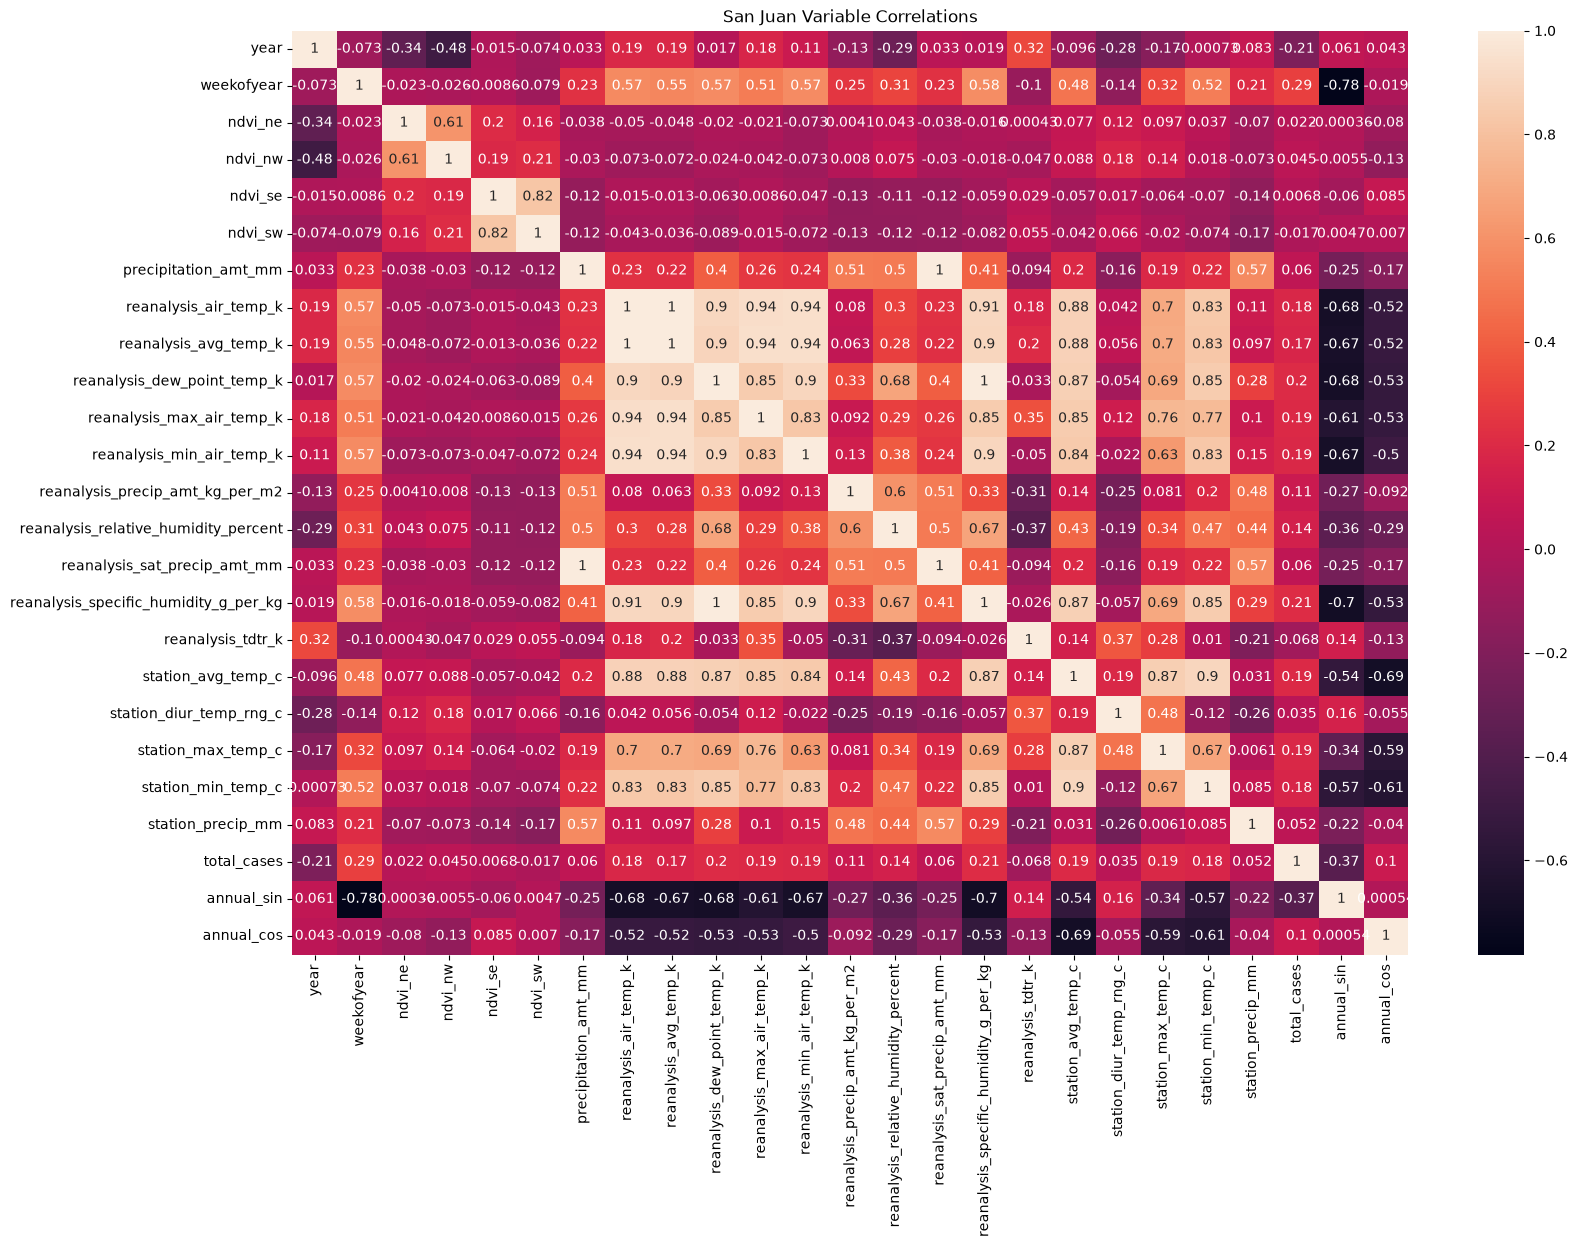

In [26]:
fig, ax = plt.subplots(figsize=(18, 12))

sj_corr_heat = sns.heatmap(sj_correlations, ax = ax,  annot = True)
plt.title("San Juan Variable Correlations");

No feature has a stong correlation with the target value, but several other features have correlations between them.

In [27]:
pairs = [
    ("precipitation_amt_mm", "reanalysis_sat_precip_amt_mm"),
    ("reanalysis_air_temp_k", "reanalysis_avg_temp_k"),
    ("reanalysis_dew_point_temp_k", "reanalysis_specific_humidity_g_per_kg"),
]

equality_check = pd.DataFrame([
    {
        "City": {"sj": "San Juan", "iq": "Iquitos"}[city],
        "Feature 1": a,
        "Feature 2": b,
        "Exactly equal": df[a].equals(df[b]),
    }
    for city, df in df_train_features.groupby("city")
    for a, b in pairs
])

display(equality_check)

,City,Feature 1,Feature 2,Exactly equal
0,Iquitos,precipitation_amt_mm,reanalysis_sat_precip_amt_mm,True
1,Iquitos,reanalysis_air_temp_k,reanalysis_avg_temp_k,False
2,Iquitos,reanalysis_dew_point_temp_k,reanalysis_specific_humidity_g_per_kg,False
3,San Juan,precipitation_amt_mm,reanalysis_sat_precip_amt_mm,True
4,San Juan,reanalysis_air_temp_k,reanalysis_avg_temp_k,False
5,San Juan,reanalysis_dew_point_temp_k,reanalysis_specific_humidity_g_per_kg,False


In [28]:
# From configs/features.yaml (model_features.drop).
excluded_due_to_correlation = [
    c for c in cfg.features.model_features.drop
    if c not in ("city", "week_start_date", "weekofyear")
]
excluded_due_to_correlation

['reanalysis_sat_precip_amt_mm']

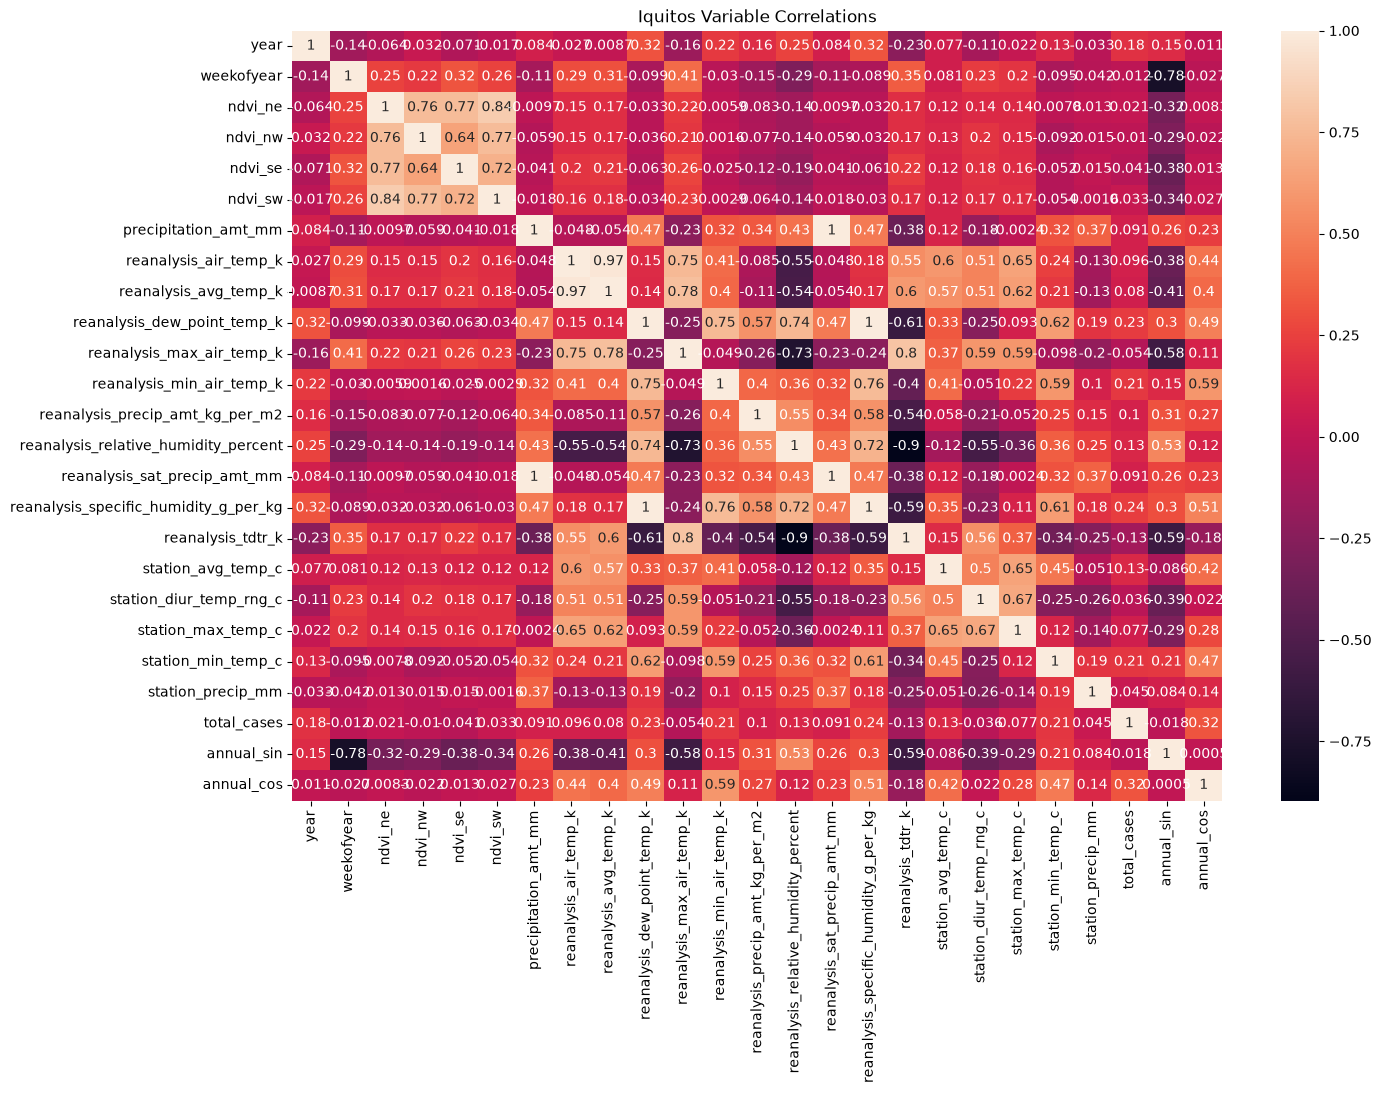

In [29]:
fig, ax = plt.subplots(figsize=(15, 10))

iq_corr_heat = sns.heatmap(iq_correlations, ax = ax,  annot = True)
plt.title("Iquitos Variable Correlations");

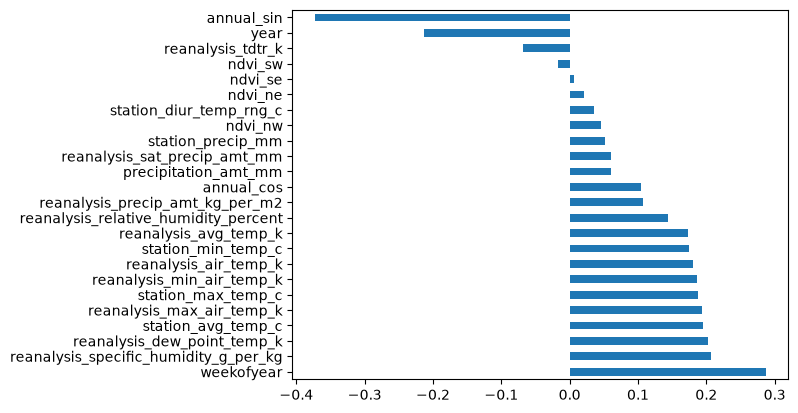

In [30]:
(
    sj_correlations.total_cases.drop("total_cases")
    .sort_values(ascending=False)
    .plot.barh()
);

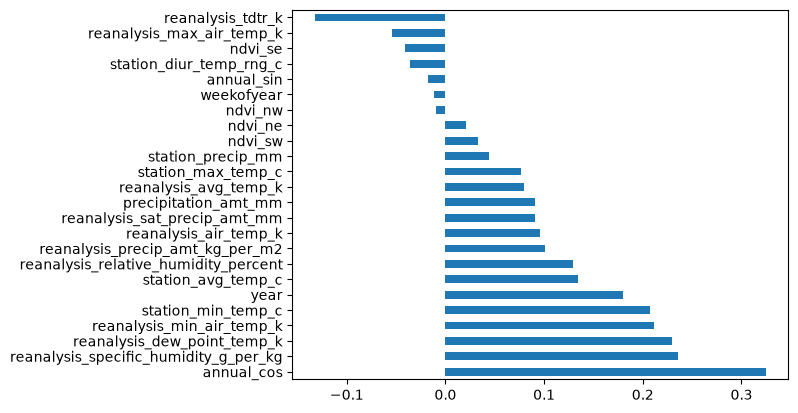

In [31]:
(
    iq_correlations.total_cases.drop("total_cases")  # don't compare with myself
    .sort_values(ascending=False)
    .plot.barh()
);

## Presentation figures

`DengAI.plots` holds the figures used in the presentation (ported from the
`plot_utils.py` module of the Part 1 deck). They are drawn from the raw training
data, so nothing here depends on the models.

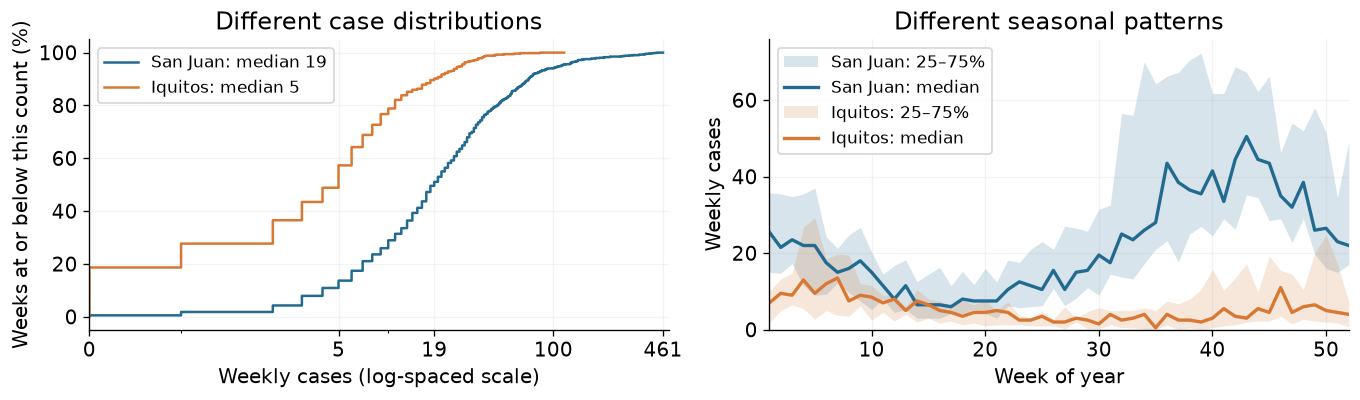

In [ ]:
from DengAI import plots

data = plots.load_data()
plots.city_patterns(data)

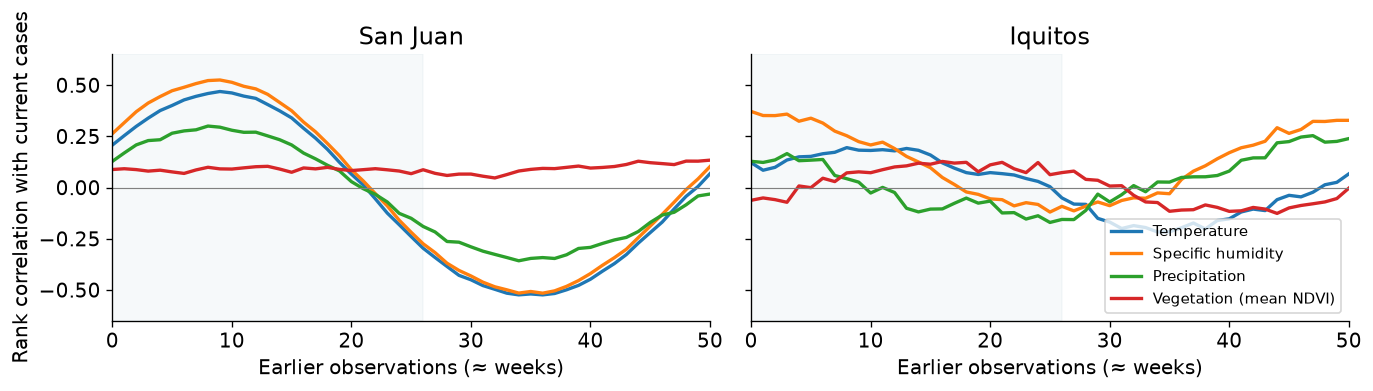

In [ ]:
plots.lag_evidence(data)

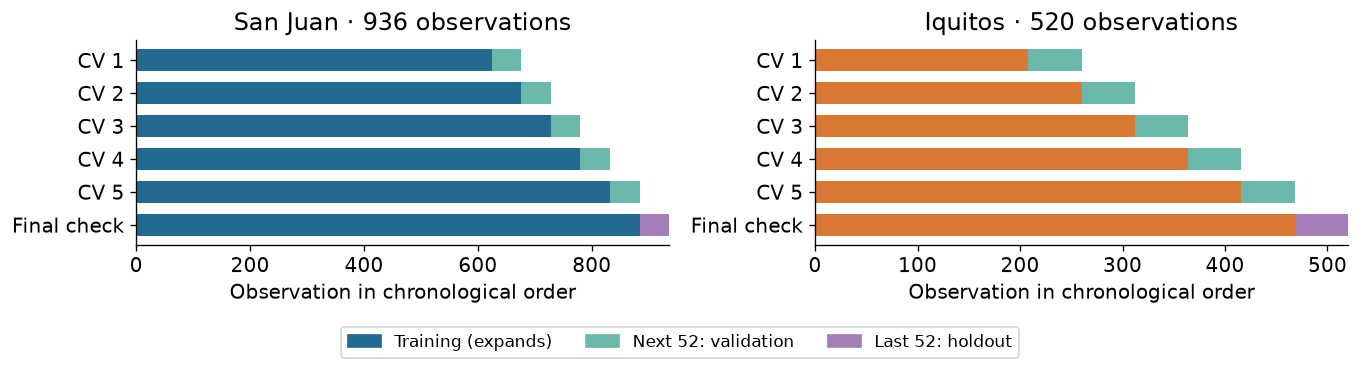

In [ ]:
plots.validation_timeline(data)

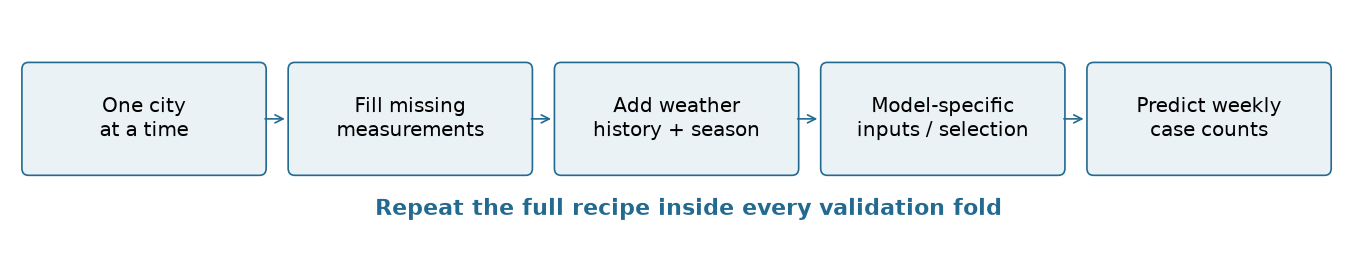

In [ ]:
plots.pipeline_diagram()

In [ ]:
plots.ndvi_missing_summary(data)

Missing (%)  Longest gap (observations)
City     Vegetation feature                                         
San Juan ndvi_ne                    20.4                          15
         ndvi_nw                     5.2                          15
         ndvi_se                     2.0                          14
         ndvi_sw                     2.0                          14
Iquitos  ndvi_ne                     0.6                           1
         ndvi_nw                     0.6                           1
         ndvi_se                     0.6                           1
         ndvi_sw                     0.6                           1

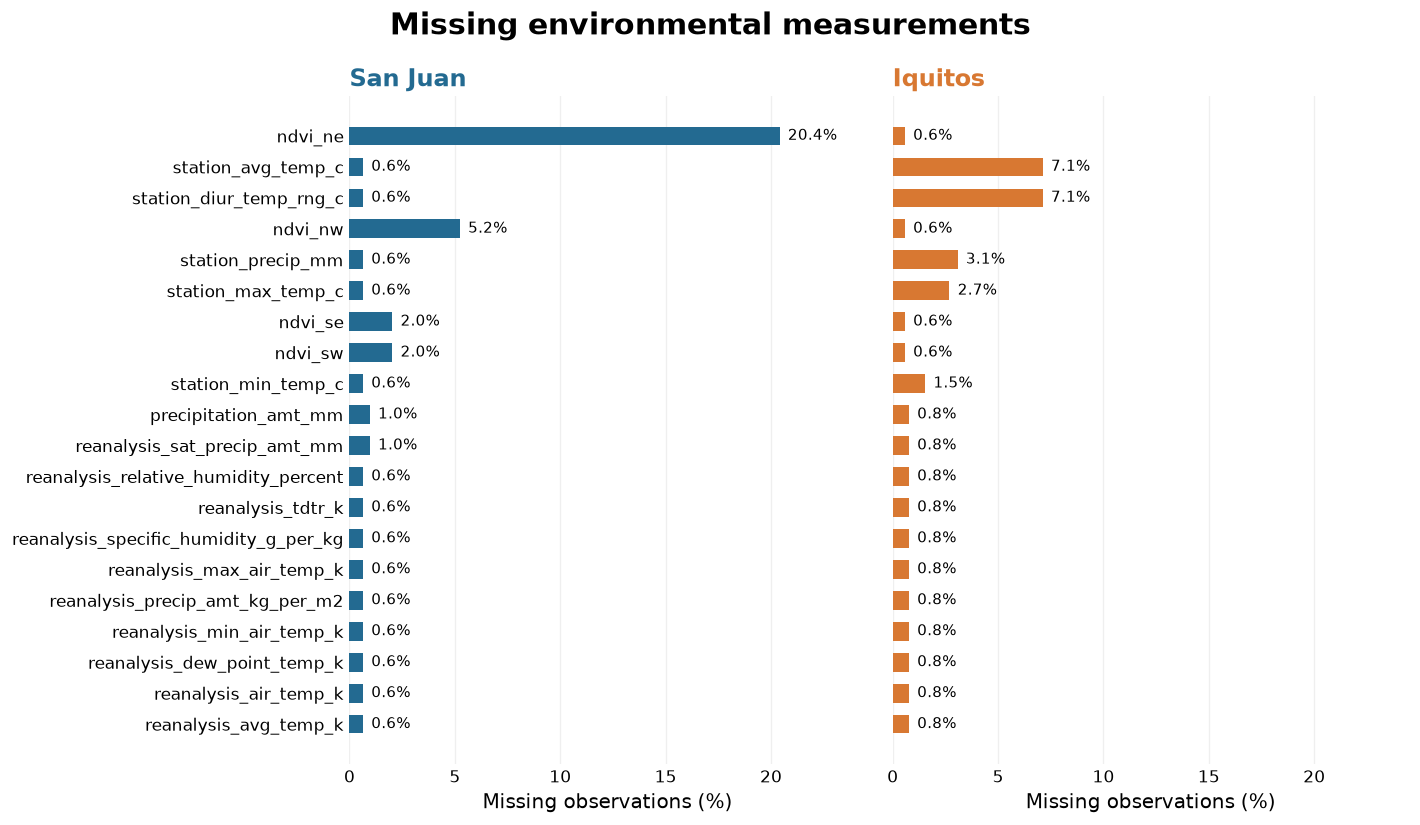

In [ ]:
plots.missingness_by_city(data)

## CatBoost feature selector

In [32]:
# CatBoostFeatureSelector now lives in DengAI/selectors.py.
# NOTE: it passes train_dir into a per-fit temp directory. catboost's
# select_features ignores allow_writing_files=False and does a bare
# mkdir("catboost_info"); with n_jobs>1 two workers race and one dies with
# FileExistsError. That is why this notebook could not previously run with
# SEARCH_JOBS=2.
catboost_params = dict(cfg.models.models.catboost.params, random_seed=RANDOM_SEED)
catboost_params

{'iterations': 1000,
 'depth': 6,
 'learning_rate': 0.02,
 'loss_function': 'MAE',
 'thread_count': 2,
 'verbose': False,
 'allow_writing_files': False,
 'random_seed': 2022}

## Prophet and SARIMAX estimators

In [33]:
# ProphetRegressor and SARIMAXRegressor now live in DengAI/models/.
import inspect
print(inspect.getsource(ProphetRegressor))
print(inspect.getsource(SARIMAXRegressor))

class ProphetRegressor(RegressorMixin, BaseEstimator):
    """Prophet with every non-date column added as an external regressor.

    Standardisation is left to the pipeline's ``StandardScaler``, hence
    ``add_regressor(..., standardize=False)``. ``__getstate__``/``__setstate__``
    serialise the Stan model through Prophet's JSON helpers so the whole
    ``Pipeline`` stays picklable.
    """

    def __init__(
        self,
        yearly_seasonality=5,
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
        seasonality_mode="additive",
        growth="linear",
        random_state=2022,
    ):
        self.yearly_seasonality = yearly_seasonality
        self.changepoint_prior_scale = changepoint_prior_scale
        self.seasonality_prior_scale = seasonality_prior_scale
        self.seasonality_mode = seasonality_mode
        self.growth = growth
        self.random_state = random_state

    def _frame(self, X):
        frame = X.rename(columns={"week_sta

# Modeling with a scikit-learn pipeline

Use the raw copies saved just after splitting the cities. The filled `sj_train_features` and `iq_train_features` remain available for EDA.

Each pipeline applies our imputer, cyclical encoding, column removal, optional CatBoost selection, and regression. `copy=True` keeps the raw copies unchanged. The data are already in chronological order.

Interpolation still uses the surrounding observations within each supplied batch; this matches the competition's supplied test features.

In [34]:
sj_y_train = sj_train_labels["total_cases"]
iq_y_train = iq_train_labels["total_cases"]

The CatBoost path retains the existing feature engineering and feature selector.
Prophet and SARIMAX reuse our city-specific imputer and weather-history transformer,
then use `time_series_columns` to choose a small set of weather inputs. Edit that
list to change both time-series models' weather features. Annual seasonality is
handled inside their estimators, so the CatBoost annual columns are not duplicated.

The time-series path also fills any remaining edge/lag NaNs with training-fold
medians and standardizes the selected weather columns using training-fold statistics.
If a selected column is entirely missing in a fold, `keep_empty_features=True`
retains it with a zero fill. CatBoost keeps its original handling of numeric NaNs.


In [35]:
# make_city_pipeline now lives in DengAI/pipelines.py. It supports four branches:
#   tree         imputer -> history -> cyclical -> features -> select -> model
#   dense        the tree steps, then impute + scale  (Ridge/Lasso reject NaN)
#   time_series  imputer -> history -> ColumnTransformer(date + weather) -> model
#   seasonal     ColumnTransformer(year, weekofyear) -> model   (calendar only)
# Which branch each model uses is declared in configs/models.yaml.

original_models = ["catboost", "prophet", "sarimax"]
pipelines = build_pipelines(cfg, names=original_models)

sj_pipeline          = pipelines["sj"]["catboost"]
iq_pipeline          = pipelines["iq"]["catboost"]
sj_prophet_pipeline  = pipelines["sj"]["prophet"]
iq_prophet_pipeline  = pipelines["iq"]["prophet"]
sj_sarimax_pipeline  = pipelines["sj"]["sarimax"]
iq_sarimax_pipeline  = pipelines["iq"]["sarimax"]

sj_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('weather_history', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,seasonal_columns,"('ndvi_ne', ...)"
,copy,True
,lag_columns,"['reanalysis_relative_humidity_percent', 'reanalysis_air_temp_k', ...]"
,mean_columns,"['reanalysis_relative_humidity_percent', 'reanalysis_air_temp_k', ...]"
,sum_columns,"['precipitation_amt_mm', 'station_precip_mm']"
,lags,"[1, 2, ...]"
,windows,"[4, 8, ...]"


## Run controls and saved models


In [36]:
# Run controls now come from configs/models.yaml.
retrain_models = {name: True for name in original_models}

# Absolute paths (repo_root/models/), so the notebook writes to the same place
# regardless of which directory the kernel was started in.
from DengAI.paths import ROOT
MODEL_DIR = ROOT / cfg.models.artifacts.dir
MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_files = {n: MODEL_DIR / f for n, f in cfg.models.artifacts.files.items()}

submission_model_by_city = dict(cfg.models.submission.model_by_city)

HOLDOUT_WEEKS = cfg.models.evaluation.holdout_weeks
CV_WEEKS      = cfg.models.evaluation.cv_weeks
CV_SPLITS     = cfg.models.evaluation.cv_splits
SEARCH_JOBS   = cfg.models.evaluation.search_jobs

print(f"holdout={HOLDOUT_WEEKS}w  cv={CV_SPLITS}x{CV_WEEKS}w  jobs={SEARCH_JOBS}")
print("models ->", MODEL_DIR)
print("submission model by city:", submission_model_by_city)

holdout=52w  cv=5x52w  jobs=2
models -> /Users/balganymtulebayeva/Machine Learning For Python/Project/models
submission model by city: {'sj': 'catboost', 'iq': 'sarimax'}


## Chronological CV and grid search

In [37]:
sj_X_dev = sj_train_raw.iloc[:-HOLDOUT_WEEKS]
sj_y_dev = sj_y_train.iloc[:-HOLDOUT_WEEKS]
sj_X_holdout = sj_train_raw.iloc[-HOLDOUT_WEEKS:]
sj_y_holdout = sj_y_train.iloc[-HOLDOUT_WEEKS:]

iq_X_dev = iq_train_raw.iloc[:-HOLDOUT_WEEKS]
iq_y_dev = iq_y_train.iloc[:-HOLDOUT_WEEKS]
iq_X_holdout = iq_train_raw.iloc[-HOLDOUT_WEEKS:]
iq_y_holdout = iq_y_train.iloc[-HOLDOUT_WEEKS:]

time_cv = TimeSeriesSplit(n_splits=CV_SPLITS, test_size=CV_WEEKS)

city_names = {"sj": "San Juan", "iq": "Iquitos"}
city_data = {
    "sj": {
        "X_dev": sj_X_dev, "y_dev": sj_y_dev,
        "X_holdout": sj_X_holdout, "y_holdout": sj_y_holdout,
        "X_train": sj_train_raw, "y_train": sj_y_train, "X_test": sj_test_raw,
    },
    "iq": {
        "X_dev": iq_X_dev, "y_dev": iq_y_dev,
        "X_holdout": iq_X_holdout, "y_holdout": iq_y_holdout,
        "X_train": iq_train_raw, "y_train": iq_y_train, "X_test": iq_test_raw,
    },
}

fold_rows = []
for city, data in city_data.items():
    for fold, (train_index, valid_index) in enumerate(time_cv.split(data["X_dev"]), 1):
        fold_rows.append({
            "City": city_names[city], "Fold": fold,
            "Train ends": data["X_dev"]["week_start_date"].iloc[train_index[-1]],
            "Validation starts": data["X_dev"]["week_start_date"].iloc[valid_index[0]],
            "Validation ends": data["X_dev"]["week_start_date"].iloc[valid_index[-1]],
        })
display(pd.DataFrame(fold_rows))


,City,Fold,Train ends,Validation starts,Validation ends
0,San Juan,1,2002-04-23,2002-04-30,2003-04-23
1,San Juan,2,2003-04-23,2003-04-30,2004-04-22
2,San Juan,3,2004-04-22,2004-04-29,2005-04-23
3,San Juan,4,2005-04-23,2005-04-30,2006-04-23
4,San Juan,5,2006-04-23,2006-04-30,2007-04-23
5,Iquitos,1,2004-06-24,2004-07-01,2005-06-25
6,Iquitos,2,2005-06-25,2005-07-02,2006-06-25
7,Iquitos,3,2006-06-25,2006-07-02,2007-06-25
8,Iquitos,4,2007-06-25,2007-07-02,2008-06-24
9,Iquitos,5,2008-06-24,2008-07-01,2009-06-25


In [38]:
# Hyperparameter grids now live in configs/models.yaml.
param_grids = ev.param_grids(cfg, names=original_models)
{k: (len(list(ParameterGrid(v))) if v else 0) for k, v in param_grids.items()}

{'catboost': 60, 'prophet': 4, 'sarimax': 6}

In [39]:
searches = {city: {} for city in city_data}
best_pipelines = {city: {} for city in city_data}
final_pipelines = {city: {} for city in city_data}

for name, retrain in retrain_models.items():
    if not retrain:
        with model_files[name].open("rb") as f:
            saved = cloudpickle.load(f)
        for city in city_data:
            final_pipelines[city][name] = saved[city]
        print(f"Loaded {name}: prediction only; no training or validation.")

for city, data in city_data.items():
    for name, retrain in retrain_models.items():
        if not retrain:
            continue
        search = GridSearchCV(
            pipelines[city][name],
            param_grids[name],
            cv=time_cv,
            scoring="neg_mean_absolute_error",
            n_jobs=SEARCH_JOBS,
            error_score=np.nan if name == "sarimax" else "raise",
        )
        n_fits = len(ParameterGrid(param_grids[name])) * time_cv.get_n_splits()
        with tqdm_joblib(total=n_fits, desc=f"{city_names[city]} / {name}", unit="fit"):
            search.fit(data["X_dev"], data["y_dev"])

        if not np.isfinite(search.best_score_):
            raise RuntimeError(f"No valid CV candidate for {city_names[city]} / {name}.")
        searches[city][name] = search
        best_pipelines[city][name] = search.best_estimator_

sj_search = searches["sj"].get("catboost")
iq_search = searches["iq"].get("catboost")
sj_best_pipeline = best_pipelines["sj"].get("catboost")
iq_best_pipeline = best_pipelines["iq"].get("catboost")

cv_frames = [
    pd.DataFrame(search.cv_results_).assign(City=city_names[city], Model=name)
    for city, city_searches in searches.items()
    for name, search in city_searches.items()
]
if cv_frames:
    cv_results = pd.concat(cv_frames, ignore_index=True)
    cv_results["CV MAE"] = -cv_results["mean_test_score"]
    display(
        cv_results[["City", "Model", "CV MAE", "params"]]
        .sort_values(["City", "CV MAE"])
        .round(3)
    )
else:
    cv_results = pd.DataFrame(columns=["City", "Model", "CV MAE", "params"])


San Juan / catboost:   0%|          | 0/300 [00:00<?, ?fit/s]

San Juan / prophet:   0%|          | 0/20 [00:00<?, ?fit/s]

10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing


10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing


10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing


10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing


10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] done processing
10:27:41 - cmdstanpy - INFO - Chain [1] start processing
10:27:42 - cmdstanpy - INFO - Chain [1] done processing
10:27:42 - cmdstanpy - INFO - Chain [1] start processing


10:27:42 - cmdstanpy - INFO - Chain [1] done processing


San Juan / sarimax:   0%|          | 0/30 [00:00<?, ?fit/s]

Iquitos / catboost:   0%|          | 0/300 [00:00<?, ?fit/s]

Iquitos / prophet:   0%|          | 0/20 [00:00<?, ?fit/s]

11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing


11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing


11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] start processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing
11:31:38 - cmdstanpy - INFO - Chain [1] done processing


11:31:39 - cmdstanpy - INFO - Chain [1] start processing
11:31:39 - cmdstanpy - INFO - Chain [1] done processing
11:31:39 - cmdstanpy - INFO - Chain [1] start processing


11:31:39 - cmdstanpy - INFO - Chain [1] done processing


Iquitos / sarimax:   0%|          | 0/30 [00:00<?, ?fit/s]

,City,Model,CV MAE,params
138,Iquitos,sarimax,6.982,"{'model__fourier_order': 3, 'model__maxiter': ..."
135,Iquitos,sarimax,6.998,"{'model__fourier_order': 2, 'model__maxiter': ..."
139,Iquitos,sarimax,6.999,"{'model__fourier_order': 3, 'model__maxiter': ..."
136,Iquitos,sarimax,7.008,"{'model__fourier_order': 2, 'model__maxiter': ..."
137,Iquitos,sarimax,7.114,"{'model__fourier_order': 3, 'model__maxiter': ..."
...,...,...,...,...
66,San Juan,sarimax,21.987,"{'model__fourier_order': 2, 'model__maxiter': ..."
67,San Juan,sarimax,22.072,"{'model__fourier_order': 3, 'model__maxiter': ..."
65,San Juan,sarimax,22.227,"{'model__fourier_order': 2, 'model__maxiter': ..."
69,San Juan,sarimax,22.513,"{'model__fourier_order': 3, 'model__maxiter': ..."


In [40]:
best_params = {
    city: {name: search.best_params_ for name, search in city_searches.items()}
    for city, city_searches in searches.items()
}

if any(searches.values()):
    with open(ROOT / "models" / "best_params_models.json", "w", encoding="utf-8") as f:
        json.dump(best_params, f, indent=2)

for city, params in best_params.items():
    print(city_names[city], params)


San Juan {'catboost': {'model__depth': 6, 'model__iterations': 1000, 'model__learning_rate': 0.02, 'select_features__n_features': 15}, 'prophet': {'model__changepoint_prior_scale': 0.05, 'model__yearly_seasonality': 5}, 'sarimax': {'model__fourier_order': 2, 'model__maxiter': 1000, 'model__order': [1, 0, 0]}}
Iquitos {'catboost': {'model__depth': 3, 'model__iterations': 500, 'model__learning_rate': 0.02, 'select_features__n_features': 40}, 'prophet': {'model__changepoint_prior_scale': 0.01, 'model__yearly_seasonality': 5}, 'sarimax': {'model__fourier_order': 3, 'model__maxiter': 1000, 'model__order': [2, 0, 0]}}


Bes params:
San Juan: {'model__depth': 4, 'model__iterations': 500, 'model__learning_rate': 0.05, 'select_features__n_features': 10}
Iquitos: {'model__depth': 4, 'model__iterations': 500, 'model__learning_rate': 0.02, 'select_features__n_features': 15}

## Holdout evaluation

In [41]:
result_rows = []
holdout_predictions = {city: {} for city in city_data}

for city, data in city_data.items():
    for name, retrain in retrain_models.items():
        if not retrain:
            result_rows.append({
                "City": city_names[city], "Model": name,
                "CV MAE": np.nan, "Holdout MAE": np.nan,
                "Status": "Loaded final model; not evaluated",
            })
            continue
        search = searches[city][name]
        predictions = best_pipelines[city][name].predict(data["X_holdout"])
        holdout_predictions[city][name] = predictions
        result_rows.append({
            "City": city_names[city], "Model": name,
            "CV MAE": -search.best_score_,
            "Holdout MAE": mean_absolute_error(data["y_holdout"], predictions),
            "Status": "Fitted on development data only",
        })

results = pd.DataFrame(result_rows).sort_values(["City", "CV MAE"])
display(results.round(3))

cv_winners = {
    city: max(city_searches, key=lambda name: city_searches[name].best_score_)
    for city, city_searches in searches.items()
    if city_searches
}
print("Lowest CV MAE among models trained in this run:", cv_winners)


,City,Model,CV MAE,Holdout MAE,Status
5,Iquitos,sarimax,6.982,4.609,Fitted on development data only
3,Iquitos,catboost,7.402,6.267,Fitted on development data only
4,Iquitos,prophet,8.140,7.161,Fitted on development data only
0,San Juan,catboost,12.229,15.021,Fitted on development data only
1,San Juan,prophet,17.177,21.783,Fitted on development data only
2,San Juan,sarimax,21.429,24.564,Fitted on development data only


Lowest CV MAE among models trained in this run: {'sj': 'catboost', 'iq': 'sarimax'}


San Juan catboost  holdout MAE: 15.021
San Juan prophet   holdout MAE: 21.783
San Juan sarimax   holdout MAE: 24.564


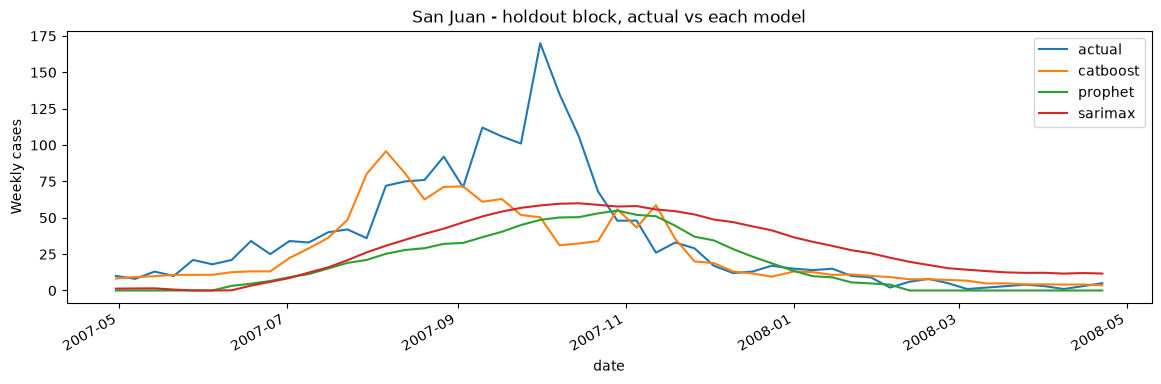

In [42]:
# holdout_predictions was filled in the previous cell from the dev-fitted
# best_pipelines, so there is nothing to refit here.
sj_comparison = pd.DataFrame(
    {"date": pd.to_datetime(sj_X_holdout["week_start_date"]).to_numpy(),
     "actual": sj_y_holdout.to_numpy(),
     **{name: pred for name, pred in holdout_predictions["sj"].items() if pred is not None}}
).set_index("date")

for name in sj_comparison.columns.drop("actual"):
    print(f"San Juan {name:9s} holdout MAE: "
          f"{mean_absolute_error(sj_y_holdout, sj_comparison[name]):.3f}")

sj_comparison.plot(figsize=(14, 4), ylabel="Weekly cases",
                   title="San Juan - holdout block, actual vs each model")
plt.show()

,Holdout MAE
sarimax,4.608897
catboost,6.266733
prophet,7.161293


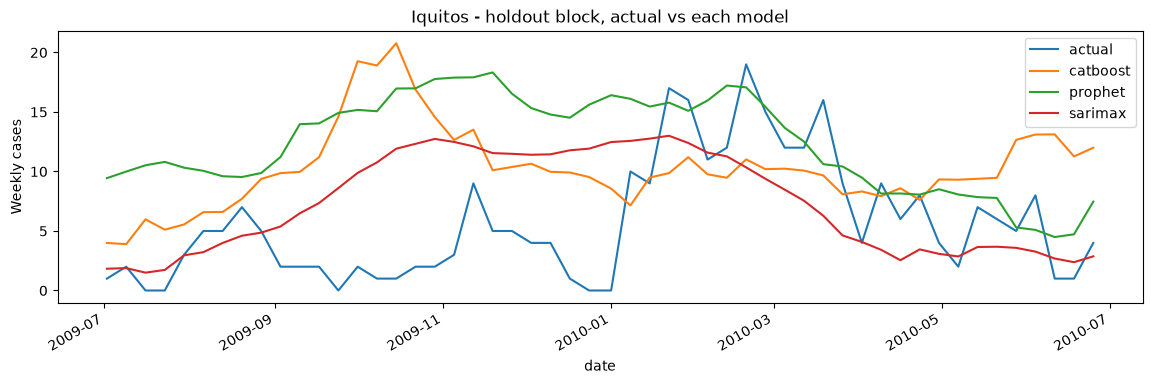

In [43]:
iq_comparison = pd.DataFrame(
    {"date": pd.to_datetime(iq_X_holdout["week_start_date"]).to_numpy(),
     "actual": iq_y_holdout.to_numpy(),
     **{name: pred for name, pred in holdout_predictions["iq"].items() if pred is not None}}
).set_index("date")

display(
    pd.Series(
        {name: mean_absolute_error(iq_y_holdout, iq_comparison[name])
         for name in iq_comparison.columns.drop("actual")},
        name="Holdout MAE",
    ).sort_values().to_frame()
)

iq_comparison.plot(figsize=(14, 4), ylabel="Weekly cases",
                   title="Iquitos - holdout block, actual vs each model")
plt.show()

In [44]:
display(
    sj_comparison.drop(columns="actual")
    .apply(lambda pred: mean_absolute_error(sj_comparison["actual"], pred))
    .sort_values()
    .rename("Holdout MAE")
    .to_frame()
)

,Holdout MAE
catboost,15.020699
prophet,21.782601
sarimax,24.564145


# Additional model experiments

Six further per-city models, built through the same `make_city_pipeline` machinery and
scored on the same chronological holdout, so they are directly comparable with CatBoost /
Prophet / SARIMAX above.

| Model | Pipeline branch | Why include it |
|---|---|---|
| **RandomForest** | `tree` | A non-boosted tree baseline on the same lag/rolling features |
| **XGBoost** | `rfe` | Gradient boosting with **Ridge-RFE feature selection** instead of the CatBoost selector, from `experiments/xgboost_feature_selection.ipynb`, where recursive elimination with a linear model beat the trees' own importances. The `rfe` branch imputes and scales *before* selecting, because Ridge cannot see NaN |
| **RidgeCV** | `dense` | Linear baseline. Needs the `dense` branch: the tree branch leaves NaNs in the lag warm-up, which trees tolerate but `RidgeCV` rejects outright |
| **LassoCV** | `dense` | As Ridge, but with built-in feature selection |
| **Seasonal median** | `seasonal` | Per-week-of-year median of past cases. **Ignores the weather entirely** |
| **Shape × level** | `seasonal` | Seasonal shape (normalised to sum 1) × median annual total |

The last two exist because of a finding from the exploratory analysis: climate reliably
predicts *when* cases rise within a year, but explains very little about *how many*.
Epidemic magnitude is driven by which dengue serotype is circulating — information absent
from this dataset. A calendar-only model makes that baseline explicit, and anything using
the weather should have to beat it.

In [45]:
extra_models = ["random_forest", "xgboost", "ridge", "lasso", "seasonal_median", "shape_level"]
extra_pipelines = build_pipelines(cfg, names=extra_models)

# Same CV folds, same holdout blocks as the three models above.
extra_searches, extra_best, extra_cv = ev.run_searches(
    extra_pipelines, city_data, cfg, names=extra_models
)
extra_hold, _ = ev.holdout_table(extra_best, city_data)
extra_results = extra_cv.merge(extra_hold, on=["City", "Model"])
display(extra_results.round(3))

  San Juan  random_forest    CV MAE  19.974


  San Juan  xgboost          CV MAE  14.202


  San Juan  ridge            CV MAE  33.293


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.268167e+02, tolerance: 2.059e+02
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.143097e+02, tolerance: 2.043e+02
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.920810e+02, tolerance: 1.854e+02
  model = cd_fast.enet_coordinate_descent_gram(


  San Juan  lasso            CV MAE  23.518
  San Juan  seasonal_median  CV MAE  15.514
  San Juan  shape_level      CV MAE  16.898


  Iquitos   random_forest    CV MAE   7.532
  Iquitos   ridge            CV MAE   9.304


  Iquitos   xgboost          CV MAE   7.851


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.175479e+00, tolerance: 2.987e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.154020e+00, tolerance: 8.847e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.877594e+00, tolerance: 8.529e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.026672e+00, tolerance: 2.987e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.748241e+00, tolerance: 2.987e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.096839e+00, tolerance: 8.847e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.270097e+00, tolerance: 8.847e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.968401e+00, tolerance: 2.950e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.012909e+00, tolerance: 8.847e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.512539e+00, tolerance: 8.847e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.738430e+00, tolerance: 8.847e-01
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.065894e+00, tolerance: 3.105e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.348577e+00, tolerance: 7.493e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.090610e+00, tolerance: 7.493e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.140820e+01, tolerance: 2.651e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.447475e+00, tolerance: 9.594e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.761237e+01, tolerance: 2.651e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.105012e+01, tolerance: 2.651e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.652559e+00, tolerance: 9.594e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.155100e+00, tolerance: 9.915e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.587574e+00, tolerance: 9.594e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.345253e+00, tolerance: 7.493e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.562718e+00, tolerance: 9.915e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.646301e+00, tolerance: 9.915e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.099866e+00, tolerance: 7.493e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.216705e+00, tolerance: 7.493e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.093274e+01, tolerance: 9.594e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.268618e+00, tolerance: 9.915e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.897716e+00, tolerance: 9.594e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.444357e+00, tolerance: 9.915e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.291592e+00, tolerance: 9.594e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.691739e+00, tolerance: 9.915e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.748192e+00, tolerance: 9.594e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.533926e+00, tolerance: 9.915e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.200736e+01, tolerance: 9.594e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.252113e+00, tolerance: 9.915e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.753797e+00, tolerance: 9.915e-01
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.086191e+00, tolerance: 3.261e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.950016e+00, tolerance: 3.123e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.684777e+00, tolerance: 3.016e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.356053e+01, tolerance: 3.261e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.237618e+00, tolerance: 3.317e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.295603e+00, tolerance: 3.123e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.330717e+00, tolerance: 3.261e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.514340e+00, tolerance: 3.123e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.485693e+00, tolerance: 3.123e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.385036e+00, tolerance: 3.317e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.342640e+00, tolerance: 3.317e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.300207e+00, tolerance: 3.123e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.594092e+00, tolerance: 3.317e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.365137e+00, tolerance: 3.556e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.029256e+01, tolerance: 3.556e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.826506e+00, tolerance: 1.256e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.008888e+00, tolerance: 1.256e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.387515e+00, tolerance: 3.294e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.257171e+00, tolerance: 1.256e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.468129e+00, tolerance: 1.256e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.177936e+00, tolerance: 1.256e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.028166e+01, tolerance: 3.294e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.577916e+00, tolerance: 1.440e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.206038e+01, tolerance: 3.294e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.237371e+00, tolerance: 1.256e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.174632e+00, tolerance: 1.440e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.666117e+00, tolerance: 1.440e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.720597e+01, tolerance: 3.294e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.409688e+00, tolerance: 1.256e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.043224e+00, tolerance: 3.556e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.183587e+00, tolerance: 1.256e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.693734e+00, tolerance: 1.256e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.343573e+00, tolerance: 1.256e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.316181e+00, tolerance: 1.256e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.484176e+00, tolerance: 3.195e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.068742e+00, tolerance: 3.195e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.113055e+00, tolerance: 3.195e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.771225e+00, tolerance: 3.457e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.594313e+00, tolerance: 3.195e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.707457e+00, tolerance: 3.457e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.335384e+00, tolerance: 3.971e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.125284e+01, tolerance: 3.971e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.359028e+01, tolerance: 3.971e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.463043e+01, tolerance: 3.971e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.878914e+00, tolerance: 4.124e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.458119e+01, tolerance: 3.971e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.157585e+00, tolerance: 4.124e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.344091e+01, tolerance: 3.971e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.334292e+00, tolerance: 2.435e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.405385e+00, tolerance: 4.155e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.473175e+00, tolerance: 2.435e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.143545e+00, tolerance: 2.435e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.327074e+00, tolerance: 2.435e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.748355e+00, tolerance: 2.435e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.042611e+01, tolerance: 2.435e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.564366e+00, tolerance: 4.155e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.123666e+00, tolerance: 3.651e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.417054e+00, tolerance: 3.651e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.968334e+00, tolerance: 3.651e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.088221e+01, tolerance: 5.285e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.415794e+00, tolerance: 5.285e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.929217e+01, tolerance: 5.408e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.738684e+01, tolerance: 5.408e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.892720e+01, tolerance: 5.408e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.332749e+00, tolerance: 3.717e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.798573e+01, tolerance: 5.408e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.923479e+00, tolerance: 3.717e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Object

/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.646728e+01, tolerance: 5.408e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.626913e+01, tolerance: 5.408e+00
  model = cd_fast.enet_coordinate_descent_gram(


/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.081314e+00, tolerance: 3.706e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/balganymtulebayeva/Machine Learning For Python/Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.985634e+00, tolerance: 3.706e+00
  model = cd_fast.enet_coordinate_descent_gram(


  Iquitos   lasso            CV MAE   7.944
  Iquitos   seasonal_median  CV MAE   6.993
  Iquitos   shape_level      CV MAE   7.324


,City,Model,CV MAE,Best params,Holdout MAE
0,San Juan,random_forest,19.974,"{'model__max_features': 0.33, 'model__min_samp...",15.157
1,San Juan,xgboost,14.202,"{'model__learning_rate': 0.03, 'model__max_depth': 6, 'model__n_estimators': 300, 'model__reg_lambda': 1, 'select_features__n_features_to_select': 25}",13.943
2,San Juan,ridge,33.293,{'select_features': 'passthrough'},24.461
3,San Juan,lasso,23.518,{'select_features': 'passthrough'},21.163
4,San Juan,seasonal_median,15.514,"{'model__smooth_window': 9, 'model__statistic'...",23.487
5,San Juan,shape_level,16.898,"{'model__shape_statistic': 'mean', 'model__smo...",20.717
6,Iquitos,random_forest,7.532,"{'model__max_features': 'sqrt', 'model__min_sa...",8.388
7,Iquitos,xgboost,7.851,"{'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 100, 'model__reg_lambda': 10, 'select_features__n_features_to_select': 25}",4.174
8,Iquitos,ridge,9.304,{'select_features': 'passthrough'},5.477
9,Iquitos,lasso,7.944,{'select_features': 'passthrough'},4.497


In [46]:
# All nine models side by side, best holdout MAE first within each city.
all_results = pd.concat([results, extra_results], ignore_index=True)
display(
    all_results[["City", "Model", "CV MAE", "Holdout MAE"]]
    .sort_values(["City", "Holdout MAE"])
    .round(3)
    .reset_index(drop=True)
)

,City,Model,CV MAE,Holdout MAE
0,Iquitos,shape_level,7.324,3.392
1,Iquitos,xgboost,7.851,4.174
2,Iquitos,seasonal_median,6.993,4.406
3,Iquitos,lasso,7.944,4.497
4,Iquitos,sarimax,6.982,4.609
5,Iquitos,ridge,9.304,5.477
6,Iquitos,catboost,7.402,6.267
7,Iquitos,prophet,8.140,7.161
8,Iquitos,random_forest,7.532,8.388
9,San Juan,xgboost,14.202,13.943


### A note on the leaderboard scores

Four of these five models were previously submitted to the real DrivenData leaderboard,
scoring **RandomForest 23.80**, **Ridge 27.00**, **seasonal median 26.46** and
**shape × level 26.00**.

Those numbers are **not** reproducible from this notebook, and the reason is worth stating
rather than hiding: they were produced from a different feature set — roughly 110 and 782
columns built by standalone scripts — whereas everything here runs through
`WeatherHistoryTransformer`'s 126 columns. The holdout MAEs above are honest re-runs on a
single consistent pipeline, not the submitted numbers.

The comparison is still informative in one specific way. Across the five models actually
submitted, local validation MAE correlated **ρ = −0.30** with the leaderboard score — mildly
*inverted* — while the number of weeks a model was willing to predict above 50 cases
correlated **ρ = −0.90**. Every validation window here is drawn from ordinary years, so it
rewards conservative prediction; the competition's test period is dominated by Puerto Rico's
2010 epidemic, the largest since surveillance began in the 1960s, which punishes exactly
that. A model can be better on this holdout and worse on the leaderboard.

## Refit the chosen pipelines for competition test predictions

In [47]:
for city, data in city_data.items():
    for name, retrain in retrain_models.items():
        if retrain:
            final_pipelines[city][name] = clone(best_pipelines[city][name]).fit(
                data["X_train"], data["y_train"]
            )

sj_final_pipeline = final_pipelines["sj"]["catboost"]
iq_final_pipeline = final_pipelines["iq"]["catboost"]
sj_final_prophet_pipeline = final_pipelines["sj"]["prophet"]
iq_final_prophet_pipeline = final_pipelines["iq"]["prophet"]
sj_final_sarimax_pipeline = final_pipelines["sj"]["sarimax"]
iq_final_sarimax_pipeline = final_pipelines["iq"]["sarimax"]

sj_selected_features = sj_final_pipeline.named_steps["model"].feature_names_
iq_selected_features = iq_final_pipeline.named_steps["model"].feature_names_

test_predictions = df_test_features[["city", "year", "weekofyear"]].copy()
for city, data in city_data.items():
    for name, pipeline in final_pipelines[city].items():
        test_predictions.loc[data["X_test"].index, f"{name}_total_cases"] = (
            pipeline.predict(data["X_test"])
        )

for city, name in submission_model_by_city.items():
    index = city_data[city]["X_test"].index
    test_predictions.loc[index, "predicted_total_cases"] = test_predictions.loc[
        index, f"{name}_total_cases"
    ]

sj_test_predictions = test_predictions.loc[sj_test_raw.index, "predicted_total_cases"].to_numpy()
iq_test_predictions = test_predictions.loc[iq_test_raw.index, "predicted_total_cases"].to_numpy()
display(test_predictions.head())


11:32:53 - cmdstanpy - INFO - Chain [1] start processing


11:32:53 - cmdstanpy - INFO - Chain [1] done processing


11:33:16 - cmdstanpy - INFO - Chain [1] start processing


11:33:16 - cmdstanpy - INFO - Chain [1] done processing


,city,year,weekofyear,catboost_total_cases,prophet_total_cases,sarimax_total_cases,predicted_total_cases
0,sj,2008,18,3.854783,0.000000,4.263804,3.854783
1,sj,2008,19,3.660433,0.000000,4.836715,3.660433
2,sj,2008,20,3.263642,0.000000,4.589525,3.263642
3,sj,2008,21,4.381066,0.000000,4.467003,4.381066
4,sj,2008,22,4.618318,0.996728,5.412797,4.618318


In [48]:
def make_submission(prediction_column):
    submission = test_predictions[
        ["city", "year", "weekofyear", prediction_column]
    ].rename(columns={prediction_column: "total_cases"}).copy()
    submission["total_cases"] = submission["total_cases"].clip(lower=0).round().astype(int)
    return submission

submission_model_by_city = {"sj": "catboost", "iq": "sarimax"}

for city, name in submission_model_by_city.items():
    index = city_data[city]["X_test"].index
    test_predictions.loc[index, "predicted_total_cases"] = (
        test_predictions.loc[index, f"{name}_total_cases"]
    )

submission = make_submission("predicted_total_cases")
submission.to_csv(ROOT / "submission.csv", index=False)

display(submission.head())

,city,year,weekofyear,total_cases
0,sj,2008,18,4
1,sj,2008,19,4
2,sj,2008,20,3
3,sj,2008,21,4
4,sj,2008,22,5


In [49]:
for name, retrain in retrain_models.items():
    if retrain:
        with model_files[name].open("wb") as f:
            cloudpickle.dump(
                {city: final_pipelines[city][name] for city in city_data}, f
            )
        print(f"Saved {name} to {model_files[name]}")


Saved catboost to /Users/balganymtulebayeva/Machine Learning For Python/Project/models/dengue_pipelines.pkl
Saved prophet to /Users/balganymtulebayeva/Machine Learning For Python/Project/models/dengue_prophet_pipelines.pkl
Saved sarimax to /Users/balganymtulebayeva/Machine Learning For Python/Project/models/dengue_sarimax_pipelines.pkl


# References

Used sources:
1. [DengAI: Predicting Disease Spread - Benchmark](https://drivendata.co/blog/dengue-benchmark/)
